## Partie 1 — Chargement et exploration

### 1.1 Chargement et constitution du corpus de titres

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import TextVectorization, Dense, Dropout, Input, Embedding, Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
from IPython.display import display, HTML
import time
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
import contractions
import joblib
import spacy
import nltk
import os
import re

In [2]:
def load_titles(filepath: str) -> pd.DataFrame :
    df = pd.read_csv(filepath)
    df = df[['title', 'label']].rename(columns= {'title':'text'})

    df['label'] = df['label'].map({'REAL' : 1, 'FAKE' : 0})

    df = df.dropna(subset= ['text'])
    df = df[df['text'].str.strip() != ""]

    len_df = len(df)
    nb_rows_by_class = df['label'].value_counts()
    avg_len = df['text'].str.len().mean()

    print("---------- Résumé ----------")
    print(f"Nombre total de titres : {len_df}")
    print(f"Nombre de lignes par classes : {nb_rows_by_class}")
    print(f"Proportions : {df['label'].value_counts(normalize= True) * 100}")
    print(f"Longueur moyenne des titres : { avg_len:.2f} caractères")

    os.makedirs('data', exist_ok=True)
    df.to_csv('../data/titles_clean.csv', index=False)
    print("Fichier sauvegardé dans '../data/titles_clean.csv'")

    return df

_ = load_titles("../data/fake_or_real_news.csv")

---------- Résumé ----------
Nombre total de titres : 6335
Nombre de lignes par classes : label
1    3171
0    3164
Name: count, dtype: int64
Proportions : label
1    50.055249
0    49.944751
Name: proportion, dtype: float64
Longueur moyenne des titres : 65.28 caractères
Fichier sauvegardé dans '../data/titles_clean.csv'


### 1.2 Analyse exploratoire
- Distribution des classes : le corpus est-il équilibré ? Si non, quelle stratégie envisagez-vous ?

Répartition des classes :
Classe 1 : 3171 titres (50.1%)
Classe 0 : 3164 titres (49.9%)


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_7248\3152932915.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_clean, palette='viridis')


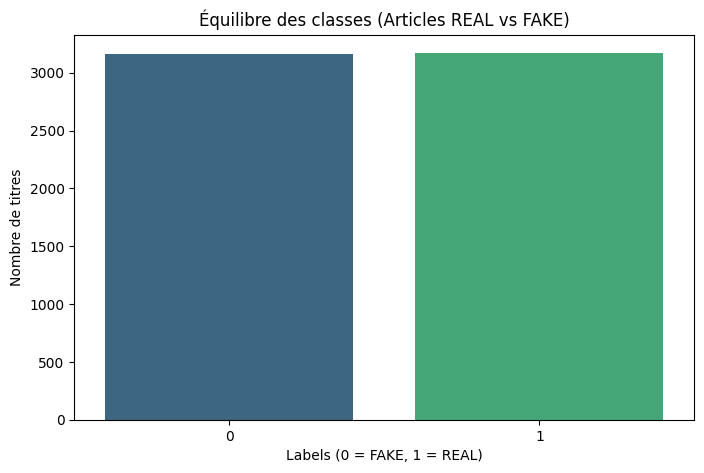

In [3]:
df_clean = pd.read_csv('../data/titles_clean.csv')

counts = df_clean['label'].value_counts()
percent = df_clean['label'].value_counts(normalize=True) * 100

print("Répartition des classes :")
for label, count in counts.items():
    print(f"Classe {label} : {count} titres ({percent[label]:.1f}%)")

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df_clean, palette='viridis')
plt.title('Équilibre des classes (Articles REAL vs FAKE)')
plt.xlabel('Labels (0 = FAKE, 1 = REAL)')
plt.ylabel('Nombre de titres')
plt.show()

Le corpus est bien équilibré, on retrouve environ 50% sur chaque classe 50.1% pour les articles vrais et 49.9% pour les articles faux. 

- Distribution de la longueur des titres en tokens : histogramme par classe, valeurs min / max / médiane

In [4]:
avg_len = df_clean['text'].str.len().mean()
min_len = df_clean['text'].str.len().min()
max_len = df_clean['text'].str.len().max()

print(f"La longueur moyenne des critiques est de : {avg_len:.2f} caractères")
print(f"Le titre le plus court contient {min_len} caractères")
print(f"Le titre le plus long contient {max_len} caractères")

La longueur moyenne des critiques est de : 65.28 caractères
Le titre le plus court contient 1 caractères
Le titre le plus long contient 289 caractères


Text(0, 0.5, 'Fréquence')

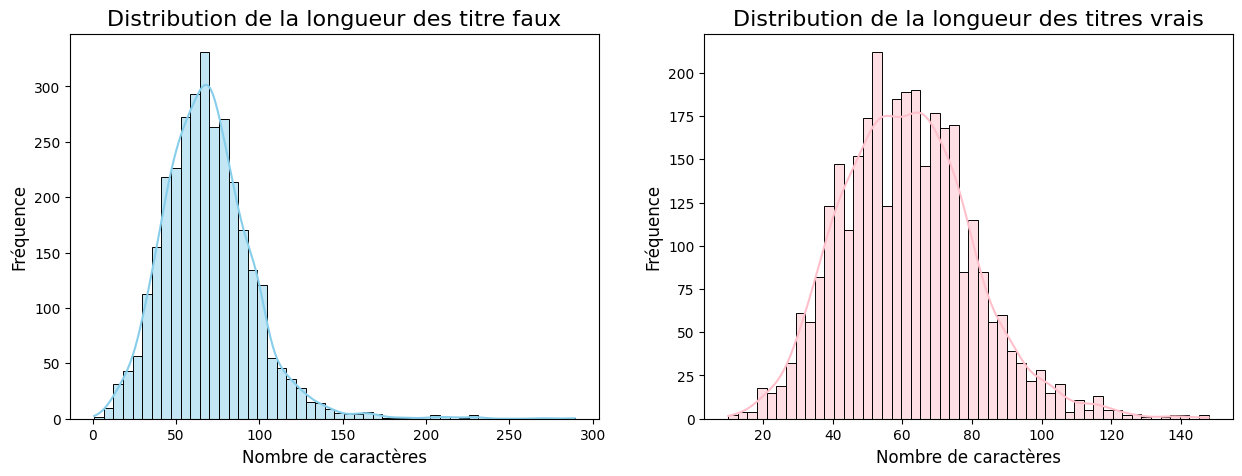

In [5]:
df_clean['title_len'] = df_clean['text'].str.len()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_clean[df_clean['label'] == 0]['title_len'], bins=50, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title("Distribution de la longueur des titre faux", fontsize=16)
ax[0].set_xlabel("Nombre de caractères", fontsize=12)
ax[0].set_ylabel("Fréquence", fontsize=12)


sns.histplot(df_clean[df_clean['label'] == 1]['title_len'], bins=50, kde=True, ax=ax[1], color='pink')
ax[1].set_title("Distribution de la longueur des titres vrais", fontsize=16)
ax[1].set_xlabel("Nombre de caractères", fontsize=12)
ax[1].set_ylabel("Fréquence", fontsize=12)

In [6]:
stats_by_class = df_clean.groupby('label')['title_len'].agg(['mean', 'min', 'max', 'median'])

print("Statistiques de longueur par classe :")
print(stats_by_class)

Statistiques de longueur par classe :
            mean  min  max  median
label                             
0      69.180784    1  289    68.0
1      61.383160   10  148    61.0


On peut remarquer avec le graphique que pour les titres Fake, il est plus fréquent d'avoir des longueurs entre 50 et 100 caractères. Tandis que pour les titres REAL, la longueur fréquente des caractères se situe d'avantage entre 40 et 80.

On remarque également dans les statistiques que les titres Fake ont une tendance aux extrêmes avec des titres allant de 1 à 289 caractères. Alors que les titres des articles REAL restent entre 10 et 148 caractères.

- Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

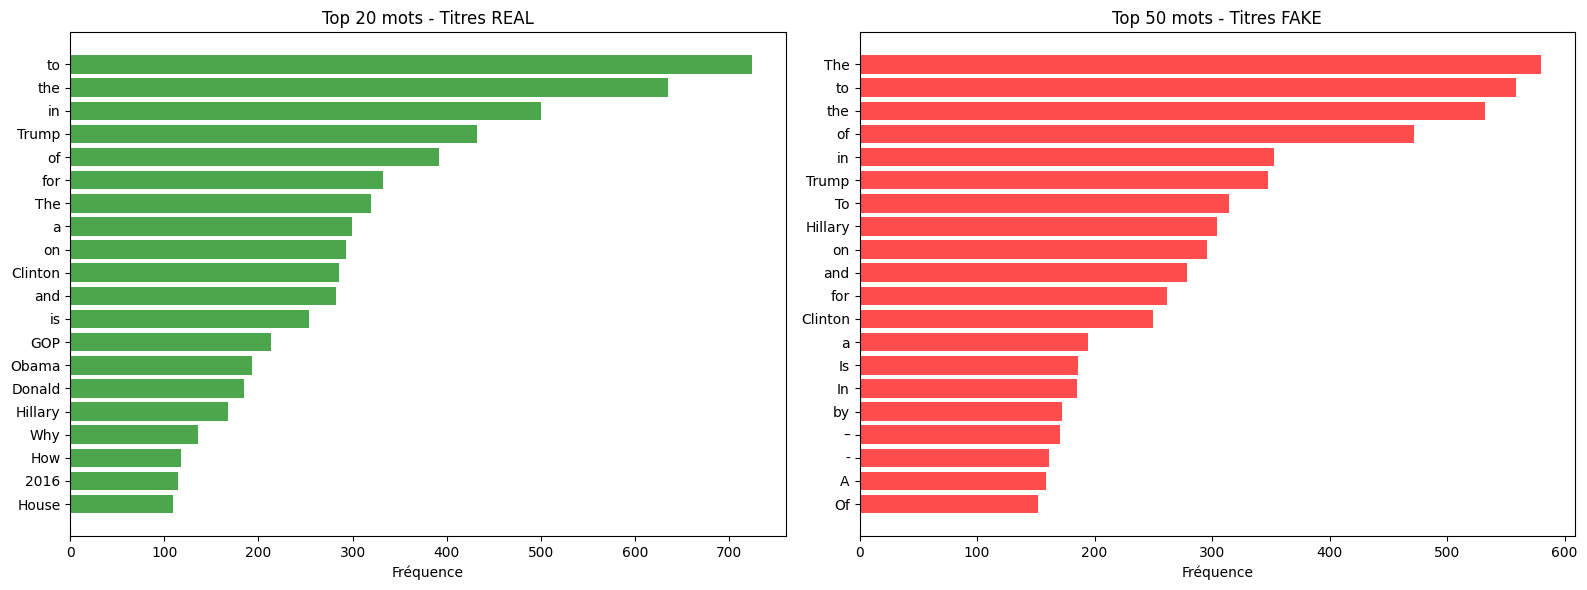

In [7]:
def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    word_freq = Counter(all_words)
    return word_freq.most_common(n)

real_titles = df_clean[df_clean['label'] == 1]['text']
top_positive = get_top_words(real_titles, 20)

fake_title = df_clean[df_clean['label'] == 0]['text']
top_negative = get_top_words(fake_title, 20)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_pos, counts_pos = zip(*top_positive)
axes[0].barh(words_pos, counts_pos, color='green', alpha=0.7)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 20 mots - Titres REAL')
axes[0].invert_yaxis()

words_neg, counts_neg = zip(*top_negative)
axes[1].barh(words_neg, counts_neg, color='red', alpha=0.7)
axes[1].set_xlabel('Fréquence')
axes[1].set_title('Top 50 mots - Titres FAKE')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

- Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe

In [8]:
def get_pure_discriminants(df, top_n=10):
    words_real = set(" ".join(df[df['label'] == 1]['text']).lower().split())
    words_fake = set(" ".join(df[df['label'] == 0]['text']).lower().split())

    pure_real = words_real - words_fake 
    pure_fake = words_fake - words_real

    all_words_real = " ".join(df[df['label'] == 1]['text']).lower().split()
    all_words_fake = " ".join(df[df['label'] == 0]['text']).lower().split()

    count_real = Counter(all_words_real)
    count_fake = Counter(all_words_fake)

    top_pure_real = sorted([(w, count_real[w]) for w in pure_real], key=lambda x: x[1], reverse=True)[:top_n]
    top_pure_fake = sorted([(w, count_fake[w]) for w in pure_fake], key=lambda x: x[1], reverse=True)[:top_n]
    
    return top_pure_real, top_pure_fake


top_real, top_fake = get_pure_discriminants(df_clean)

print("--- Top 10 Tokens Discriminants PURS (REAL) ---")
for word, freq in top_real:
    print(f"{word}: {freq}")

print("\n--- Top 10 Tokens Discriminants PURS (FAKE) ---")
for word, freq in top_fake:
    print(f"{word}: {freq}")

--- Top 10 Tokens Discriminants PURS (REAL) ---
(+video): 67
jeb: 50
marriage: 30
rand: 24
bid: 23
convention: 22
polarization: 20
takeaways: 20
hampshire: 20
boehner: 19

--- Top 10 Tokens Discriminants PURS (FAKE) ---
:: 54
(video): 42
re:: 40
truthfeed: 33
breaking:: 32
finest: 30
[video]: 26
gold: 22
podesta: 18
fraud: 18


On observe bien une différence entre les titres REAL et FAKE. Dans les titres FAKE, on trouve des mots chargés d'émotions ou de conspiration (fraud, gold), on y trouve également truthfeed, connu pour diffuser des infox. Contrairement aux titres REAL où le vocabulaire est plus politique et institutionnel (convention, nomination, hampshire).

On peur remarquer également une différence dans la ponctuation et le formatage. Dans les tokens de la clase FAKE, on remarque beaucoup d'incohérence (::, re:, breaking ::). Il y a également une différence dans le formatage des vidéos : 
- (+video) pour les titres REAL
- (video) pour les titres FAKE


- Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème

In [9]:
words_real = Counter(" ".join(df_clean[df_clean['label'] == 1]['text']).lower().split())
words_fake = Counter(" ".join(df_clean[df_clean['label'] == 0]['text']).lower().split())

def calculate_ambiguity_score(text):
    words = text.lower().split()
    score = 0
    for w in words:
        total = words_real[w] + words_fake[w]
        if total > 10: 
            ratio = words_real[w] / total
            score += abs(ratio - 0.5)
    return score / len(words) if len(words) > 0 else 1

df_clean['ambiguity_score'] = df_clean['text'].apply(calculate_ambiguity_score)
ambiguous_titles = df_clean.sort_values(by='ambiguity_score').head(3)

print(ambiguous_titles[['text', 'label']])

                                                   text  label
2839      (The Onion) Strongside/Weakside: Theo Epstein      0
57                Closed primaries, 'warped' democracy?      1
5678  MUFON International tracking multiple triangle...      0


Voilà les 3 exemples sortis :
- 2839      (The Onion) Strongside/Weakside: Theo Epstein      0
- 57                Closed primaries, 'warped' democracy?      1
- 5678  MUFON International tracking multiple triangle...      0

- Le premier exemple est assez explicite : The Onion est un journal satirique, quand nous le voyons, nous pensons tout de suite que c'est faux. Cependant le titre utilise un vocabulaire analytique sérieux, qui ne montre pas à l'IA que c'est un FAKE. Si le modèle n'a pas appris que le mot clé "The Onion" est un indicateur de parodie, il classera probablement ce titre comme REAL car la structure est propren sans ponctuation excessive no majuscules agressives. 

- Dans le deuxième exemple, l'ambiguïté vient de la ponctuation fortement présente sur un titre aussi court. 

- Concernant le troisième exemple, la structure grammaticale est proche de celle d'une news de la NASA ou du FBI, donc en apparence il s'agit de quelque chose de sérieux. Cependant MUFON concerne le paranormal, il s'agit d'une organisation qui suit les OVNI. 

## Partie 2 — Nettoyage et prétraitement

### 2.1 Pipeline de nettoyage

In [10]:
nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm", disable= ["parser", "ner"])

def clean_title(text: str) -> str :
    # mise en minuscule
    text = text.lower()

    # Suppresion des urls et des mentions de type '@username'
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)

    # ponctuaction
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Expansion des contractions (installation des contractions)
    text = contractions.fix(text)

    # Stopwords
    stop_words = set(stopwords.words('english'))
    word_negations = {'not', 'no', 'never', 'neither'}
    filtered_stops = stop_words - word_negations

    # Lemmatisation
    doc = nlp(text)

    # Suppression des tokens < 2 après lemmatisation
    cleaned_tokens = [
        token.lemma_ for token in doc 
        if token.lemma_ not in filtered_stops 
        and not token.is_space 
        and len(token.lemma_) > 1
    ]

    return " ".join(cleaned_tokens)


df_clean['text_clean'] = df_clean['text'].apply(clean_title)
print(df_clean['text_clean'])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0                                     smell hillarys fear
1       watch exact moment paul ryan commit political ...
2                         kerry go paris gesture sympathy
3       bernie supporter twitter erupt anger dnc try warn
4                          battle new york primary matter
                              ...                        
6330    state department say not find email clinton sp...
6331                       pbs stand plutocratic pentagon
6332       antitrump protester tool oligarchy information
6333    ethiopia obama seek progress peace security ea...
6334                jeb bush suddenly attack trump matter
Name: text_clean, Length: 6335, dtype: str


### 2.2 Mesure de l'impact du nettoyage

In [11]:
def get_vocab_size(series):
    words = " ".join(series.astype(str)).split()
    return len(set(words))

vocab_before = get_vocab_size(df_clean['text'])
vocab_after = get_vocab_size(df_clean['text_clean'])

tokens_before = df_clean['text'].str.split().str.len().mean()
tokens_after = df_clean['text_clean'].str.split().str.len().mean()

titles_empty = df_clean[df_clean['text_clean'].str.strip() == ""]
nb_empty = len(titles_empty)

print(f"--- Impact du Nettoyage ---")
print(f"Taille du vocabulaire : {vocab_before} -> {vocab_after} (Réduction de {((vocab_before-vocab_after)/vocab_before)*100:.1f}%)")
print(f"Longueur moyenne : {tokens_before:.2f} tokens -> {tokens_after:.2f} tokens")
print(f"Réduction moyenne : {tokens_before - tokens_after:.2f} tokens par titre")
print(f"Titres devenus vides : {nb_empty}")

--- Impact du Nettoyage ---
Taille du vocabulaire : 17955 -> 8409 (Réduction de 53.2%)
Longueur moyenne : 10.50 tokens -> 7.43 tokens
Réduction moyenne : 3.07 tokens par titre
Titres devenus vides : 3


Gestion des titres devenus vides après nettoyage : 
- un titre vide n'a aucun sens, il ne donne aucun détail et ne permet pas d'aider l'IA à identifier si les articles sont REAL ou FAKE. 
- Cela risque d'introduire du bruit ou des erreurs lors de la phase de vectorization.

*Resultat* : je préconise de supprimer les lignes où le titre est vide. 

In [12]:
df_clean = df_clean[df_clean['text_clean'].str.strip() != ""]
print(f"Nombre de titres vides après suppression : {nb_empty}")

Nombre de titres vides après suppression : 3


**Question écrite :** Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus.

*Resultat*: Parce qu'un article vrai qui dirait une chose et un article faux qui dirait le contraire de cette même chose (par exemple : Trump est fou (en REAL), Trump n'est pas fou (en FAKE)(Attention, tout lien avec une personne existante et connue est totalement voulu XD)), transformerait complètement la phrase négative, les deux deviendraient identiques. Et on ne saurait plus différencier ce qui est vrai, de ce qui est faux.  

## Partie 3 — Représentation vectorielle

### 3.1 Vectorisation TF-IDF

In [13]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_clean['text_clean'],
    df_clean['label'],
    test_size= 0.2,
    random_state= 42
)

vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)


os.makedirs('../models', exist_ok=True)
joblib.dump(vectorizer, '../models/vectorizer.pkl')

print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test : {X_test.shape}")
print("Vectoriseur sauvegardé dans '../models/vectorizer.pkl'")

Dimensions de X_train : (5065, 3000)
Dimensions de X_test : (1267, 3000)
Vectoriseur sauvegardé dans '../models/vectorizer.pkl'


### 3.2 Embedding avec TensorFlow

In [14]:
max_tokens = 5000
output_sequence_length = 30

vectorize_layer = TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=output_sequence_length
)

vectorize_layer.adapt(df_clean['text'].values)

vocab = vectorize_layer.get_vocabulary()
print(f"Taille du vocabulaire retenu : {len(vocab)}")
print(f"Exemple de tokens : {vocab[:10]}")

Taille du vocabulaire retenu : 5000
Exemple de tokens : ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('in'), np.str_('of'), np.str_('trump'), np.str_('for'), np.str_('on'), np.str_('a')]


**Question écrite :** Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? 

*Réponse* :
- Vecteur TF-IDF (Représentation "Sparse" ou Creuse) : Approche purement statistique basée sur la fréquence. Chaque mot du vocabulaire correspond à une dimension (une colonne) unique. 
- Vecteur d'Embedding (Représentation "Dense" ou Continue) : Approche géométrique. Chaque mot est projeté dans un espace vectoriel de dimension réduite. Au lieu d'être une simple coordonnée, le mot est un point dans un espace mutli-dimensionnel. Les valeurs ne sont pas des fréquences, mais des poids appris par le réseau de neurones. 

**Question écrite :** Laquelle de ces deux représentations est capable de capturer que `misleading` et `deceptive` sont sémantiquement proches ?

*Réponse* : C'est la représentation par Embedding appris qui est capable de capturer que ces deux mots sont sémantiquement proches. 
- Pour le TF-IDF : `misleading` et `deceptive` sont deux colonnes distinctes. Le modèle n'a aucun moyen de savoir qu'ils expriment la même idée. 
- Pour l'Embedding : lors de l'entraînement, le modèle observe que `misleading` et `deceptive` apparaissent dans des contextes similaires. Pour optimiser sa prédiction, le réseau va donc natuellement rapprocher ces deux points dans son espace vectoriel. 


## Partie 4 — Modélisation

### 4.1 Modèle baseline — réseau dense sur TF-IDF

In [15]:
model_tfidf = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_tfidf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,281 (3.06 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model_tfidf.compile(
    optimizer= 'adam',
    loss= 'binary_crossentropy',
    metrics= ['accuracy']
)

callbacks = [
    EarlyStopping(
        patience= 5,
        restore_best_weights= True,
        monitor= 'val_loss'
    ),
    ModelCheckpoint(
        filepath= '../models/best_models_tfidf.keras',
        monitor= 'val_loss',
        save_best_only= True
    )
]

start_tfidf = time.time()
history = model_tfidf.fit(
    X_train.toarray(), y_train,
    epochs = 30,
    batch_size = 32,
    validation_split = 0.15,
    callbacks= callbacks,
    verbose= 1
)
duration_tfidf = time.time() - start_tfidf

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6983 - loss: 0.5930 - val_accuracy: 0.8053 - val_loss: 0.4469
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8702 - loss: 0.3148 - val_accuracy: 0.8053 - val_loss: 0.4625
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9292 - loss: 0.1844 - val_accuracy: 0.7855 - val_loss: 0.5747
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9659 - loss: 0.1008 - val_accuracy: 0.7908 - val_loss: 0.7006
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9882 - loss: 0.0493 - val_accuracy: 0.7803 - val_loss: 0.8025
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9954 - loss: 0.0226 - val_accuracy: 0.7895 - val_loss: 0.9289


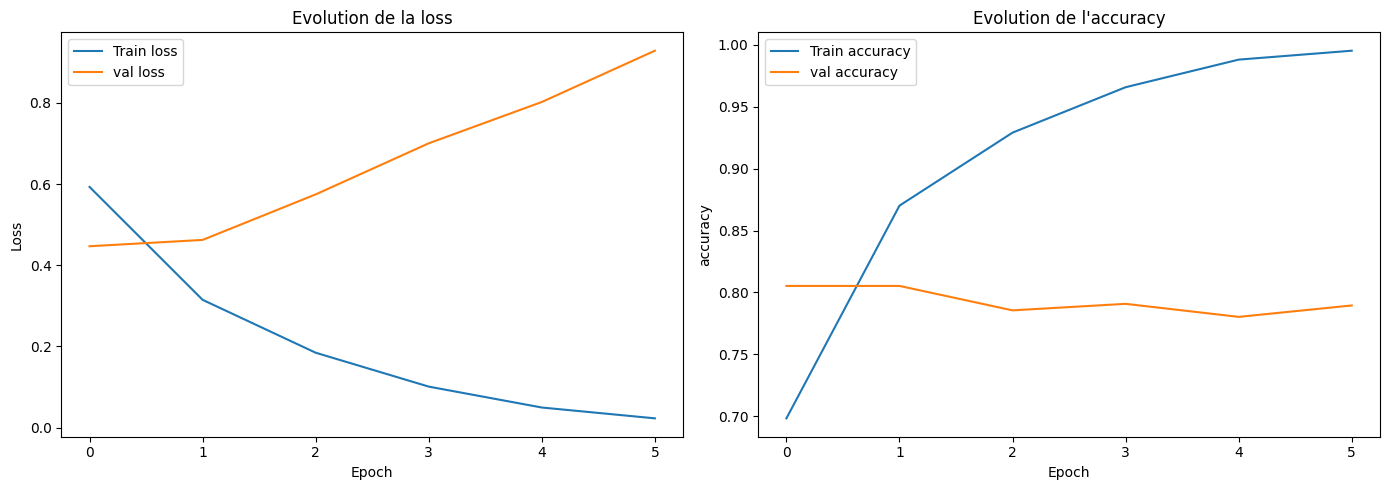

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

# loss
ax1.plot(history.history["loss"], label = "Train loss")
ax1.plot(history.history["val_loss"], label = "val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Evolution de la loss")
ax1.legend()

# accuracy
ax2.plot(history.history["accuracy"], label = "Train accuracy")
ax2.plot(history.history["val_accuracy"], label = "val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("accuracy")
ax2.set_title("Evolution de l'accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

### 4.2 Modèle avec embeddings appris — architecture séquentielle

In [18]:
model_embed = Sequential([
    vectorize_layer,
    Embedding(input_dim=5000, output_dim=64, mask_zero=True),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_embed(X_train_text[:2])
model_embed.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (2, 30)                │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (2, 30, 64)            │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (2, 128)               │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (2, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (2, 64)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (2, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,369 (1.50 MB)

 Trainable params: 394,369 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model_embed.compile(
    optimizer= 'adam',
    loss= 'binary_crossentropy',
    metrics= ['accuracy']
)

X_train_tensor = tf.convert_to_tensor(X_train_text.values, dtype=tf.string)
y_train_tensor = tf.convert_to_tensor(y_train.values, dtype=tf.float32)

start_embed = time.time()
history_embed = model_embed.fit(
    X_train_tensor, 
    y_train_tensor,
    epochs = 30,
    batch_size = 32,
    validation_split = 0.15,
    callbacks= callbacks,
    verbose= 2
)
duration_embed = time.time() - start_embed

Epoch 1/30
135/135 - 6s - 45ms/step - accuracy: 0.7034 - loss: 0.5527 - val_accuracy: 0.7789 - val_loss: 0.4469
Epoch 2/30
135/135 - 2s - 16ms/step - accuracy: 0.8667 - loss: 0.3189 - val_accuracy: 0.7921 - val_loss: 0.4508
Epoch 3/30
135/135 - 2s - 16ms/step - accuracy: 0.9187 - loss: 0.2180 - val_accuracy: 0.7961 - val_loss: 0.5102
Epoch 4/30
135/135 - 2s - 16ms/step - accuracy: 0.9438 - loss: 0.1612 - val_accuracy: 0.7895 - val_loss: 0.5737
Epoch 5/30
135/135 - 2s - 16ms/step - accuracy: 0.9577 - loss: 0.1164 - val_accuracy: 0.7934 - val_loss: 0.6752


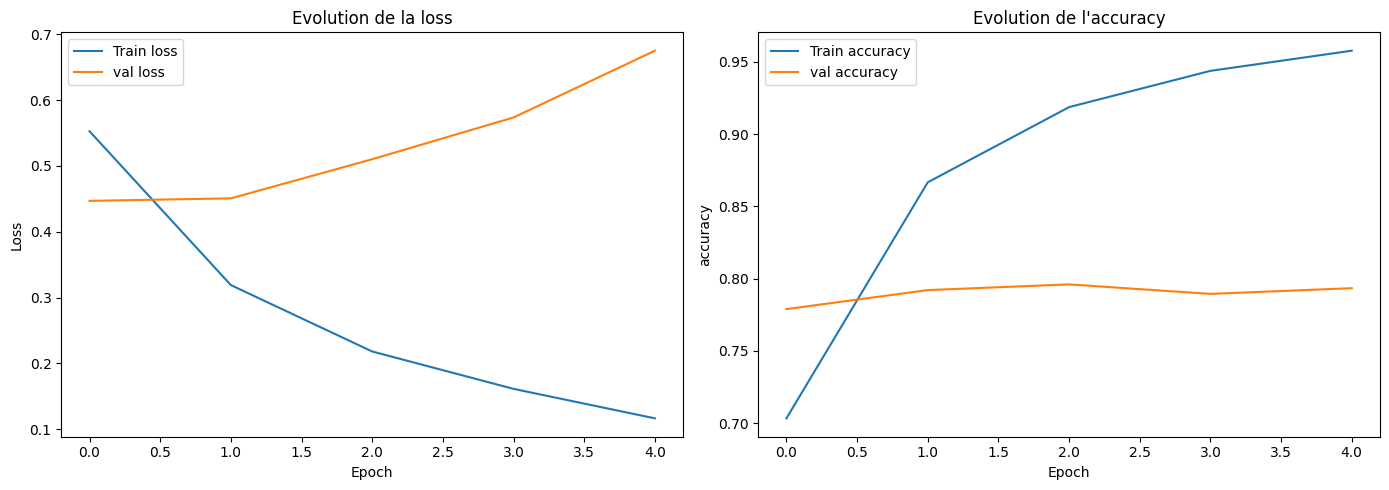

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

# loss
ax1.plot(history_embed.history["loss"], label = "Train loss")
ax1.plot(history_embed.history["val_loss"], label = "val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Evolution de la loss")
ax1.legend()

# accuracy
ax2.plot(history_embed.history["accuracy"], label = "Train accuracy")
ax2.plot(history_embed.history["val_accuracy"], label = "val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("accuracy")
ax2.set_title("Evolution de l'accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

### 4.3 Comparaison des deux architectures

In [21]:
def get_model_metrics(model, X_test_data, y_test, is_tfidf=False):
    start_time = time.time()
    if is_tfidf:
        data = X_test_data.toarray()
    else:
        data = tf.convert_to_tensor(np.array(X_test_data).astype(str), dtype=tf.string)

    y_pred_prob = model.predict(data)
    y_pred = (y_pred_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
    f1_macro = precision_recall_fscore_support(y_test, y_pred, average='macro')[2]
    auc = roc_auc_score(y_test, y_pred_prob)
    
    return {
        "acc": acc,
        "prec_fake": precision[0],
        "rec_fake": recall[0],
        "f1_macro": f1_macro,
        "auc": auc
    }


metrics_tfidf = get_model_metrics(model_tfidf, X_test, y_test, is_tfidf=True)
metrics_embed = get_model_metrics(model_embed, X_test_text, y_test, is_tfidf=False)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [22]:
def format_time(seconds):
    if seconds < 60:
        return f"{seconds:.2f}s"
    return f"{int(seconds // 60)}m {int(seconds % 60)}s"

data = {
    "Critère": [
        "Accuracy (test)", 
        "Precision — classe FAKE", 
        "Recall — classe FAKE", 
        "F1-score (macro)", 
        "AUC-ROC",
        "Epochs effectifs (EarlyStopping)",
        "Nombre de paramètres entraînables",
        "Temps d'entraînement (approx.)"
    ],
    "Modèle Dense (TF-IDF)": [
        f"{metrics_tfidf['acc']:.4f}",
        f"{metrics_tfidf['prec_fake']:.4f}",
        f"{metrics_tfidf['rec_fake']:.4f}",
        f"{metrics_tfidf['f1_macro']:.4f}",
        f"{metrics_tfidf['auc']:.4f}",
        len(history.history['loss']), 
        f"{model_tfidf.count_params():,}",
        format_time(duration_tfidf)
    ],
    "Modèle LSTM Bidirectionnel": [
        f"{metrics_embed['acc']:.4f}",
        f"{metrics_embed['prec_fake']:.4f}",
        f"{metrics_embed['rec_fake']:.4f}",
        f"{metrics_embed['f1_macro']:.4f}",
        f"{metrics_embed['auc']:.4f}",
        len(history_embed.history['loss']),
        f"{model_embed.count_params():,}",
        format_time(duration_embed)
    ]
}


df_comparaison = pd.DataFrame(data)



display(HTML(df_comparaison.to_html(index=False)))

Critère,Modèle Dense (TF-IDF),Modèle LSTM Bidirectionnel
Accuracy (test),0.8193,0.8122
Precision — classe FAKE,0.8022,0.8304
Recall — classe FAKE,0.8371,0.7742
F1-score (macro),0.8193,0.8116
AUC-ROC,0.8889,0.8863
Epochs effectifs (EarlyStopping),6,5
Nombre de paramètres entraînables,"801,281","394,369"
Temps d'entraînement (approx.),3.12s,14.85s


**Question écrite :** Lequel des deux modèles recommanderiez-vous pour une mise en production ? Justifiez votre choix en tenant compte à la fois des performances et des contraintes opérationnelles (temps de réponse, maintenance, volume de données).

*Réponse* : Je recommande le modèle Dense TF-IDF. Bien que les performances soient extrêmement proches (81.9% pour TF-IDF et 81.2% pour LSTM), il y a plusieurs points qui les départagent à mes yeux : 
- Temps d'entraînement : TF-IDF est environ 5 fois plus rapide. Dans un contexte réel avec des millions de données, cette différence permettrait des économies de temps, d'énergie et de coûts de serveurs significatifs. 
- Complexité : Dans le fonctionnement, le modèle TF-IDF est plus simple à déboguer. On peut facilement tracer quel token a poussé le modèle à classer un titre en "FAKE". Contrairement au LSTM qui est plus complexe et dont le comportement est plus difficile à interpréter. 
- Le fait qu'il y ai plus du double de paramètres entraînable chez le modèle TF-IDF par rapport à LSTM et que malgré tout il n'y ai que 1 epoch de plus, m'indique qu'il est extrêmement performant. Cela montre que pour des séquences courtes (titres), la présence de mots-clés est un signal plus fort et plus facile à capturer.

## Partie 5 — Évaluation approfondie

### 5.1 Analyse des performances du meilleur modèle

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


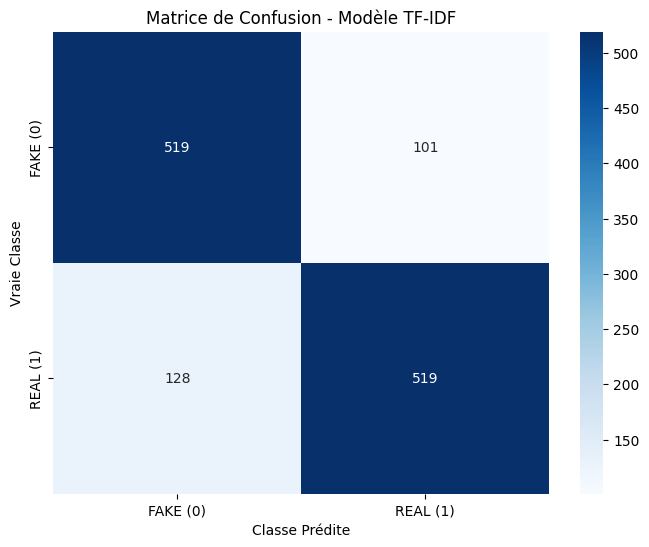


Rapport de classification détaillé :
              precision    recall  f1-score   support

        FAKE       0.80      0.84      0.82       620
        REAL       0.84      0.80      0.82       647

    accuracy                           0.82      1267
   macro avg       0.82      0.82      0.82      1267
weighted avg       0.82      0.82      0.82      1267



In [23]:
y_pred_prob = model_tfidf.predict(X_test.toarray())
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['FAKE (0)', 'REAL (1)'], 
            yticklabels=['FAKE (0)', 'REAL (1)'])

plt.title('Matrice de Confusion - Modèle TF-IDF')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()


print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred, target_names=['FAKE', 'REAL']))

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


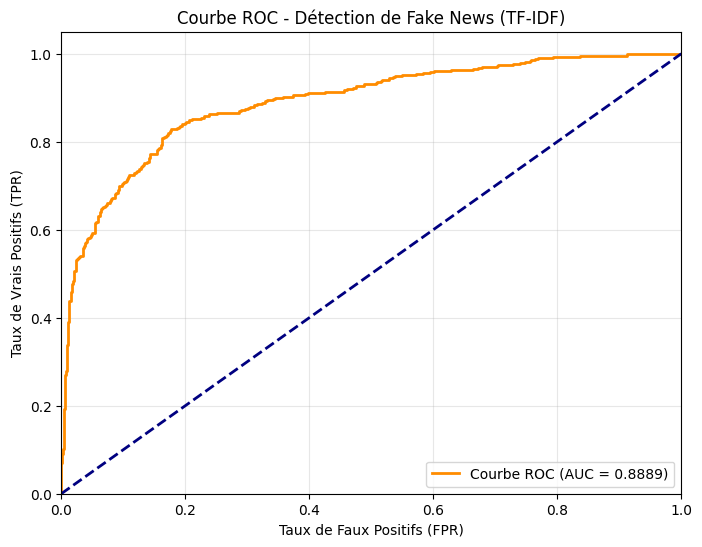

In [24]:
y_pred_prob = model_tfidf.predict(X_test.toarray()).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Détection de Fake News (TF-IDF)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### 5.2 Analyse des erreurs

In [25]:
indices_test = y_test.index

results_df = pd.DataFrame({
    'title_brut' : df_clean.loc[indices_test, 'text'], 
    'title' : X_test_text.values,
    'label_real' : y_test.values,
    'probability' : y_pred_prob 
})

fp_mask = (results_df['label_real'] == 1) & (results_df['probability'] < 0.5)
fake_positive = results_df[fp_mask].copy()
fake_positive['trust'] = 1 - fake_positive['probability']
top_15_fp = fake_positive.sort_values(by = 'trust', ascending= False).head(15)

fn_mask = (results_df['label_real'] == 0) & (results_df['probability'] >= 0.5) 
fake_negative = results_df[fn_mask].copy()
fake_negative['trust'] = fake_negative['probability']
top_15_fn = fake_negative.sort_values(by = 'trust', ascending= False).head(15) 

print("TOP 15 FAUX POSITIFS (Le modèle a cru fermement que c'était FAKE alors que c'est REAL)")
display(top_15_fp[['title_brut', 'trust']])

print("TOP 15 FAUX NÉGATIFS (Le modèle a cru fermement que c'était REAL alors que c'est FAKE)")
display(top_15_fn[['title_brut', 'trust']])

TOP 15 FAUX POSITIFS (Le modèle a cru fermement que c'était FAKE alors que c'est REAL)


,title_brut,trust
1057,Will Hillary Clinton lose the election because...,0.955244
5131,The Collectivist Election,0.942203
5891,The no-transparency election,0.942203
1507,There’s nothing suspicious about Trump’s accus...,0.928616
1789,"Turkey, Russia Headed for a Military Face-Off?",0.918851
3290,The teachable moment of Saudi Arabia’s economi...,0.906724
1514,Who will Hillary Clinton’s ‘basket of deplorab...,0.901785
4517,America is criminalizing Black teachers: Atlan...,0.898318
5419,Trudeau Elected Canada's Prime Minister As Lib...,0.896662
2571,Michael Brown's Family To File Wrongful Death ...,0.894987


TOP 15 FAUX NÉGATIFS (Le modèle a cru fermement que c'était REAL alors que c'est FAKE)


,title_brut,trust
5318,The Battleship Debate,0.980109
3998,Checkmating Obama,0.976979
151,Classless Obama Refuses Photo-Op of White Hous...,0.975475
5380,Statistical Tie: Latest Breitbart/Gravis Poll ...,0.956577
6019,Paul Ryan Must Step Down as Speaker of the House,0.940213
3632,Candace Cameron Bure Dishes on the Main Conser...,0.937680
3809,Saudis Foil ISIS Terror Attacks on Packed Stadium,0.916410
4408,Debate: Washington's Syria policy,0.899289
3815,Canada and EU sign ‘thoroughly undemocratic’ C...,0.883723
333,Iraq’s Skies Darken as Islamic State Torches Oil,0.883133


**Questions** : Quels patterns linguistiques communs observez-vous ? Le modèle semble-t-il sensible à certains mots ou structures de phrase ?

*Réponse* : 
- Les faux positifs : 
    - Il s'avère que plusieurs de ces titres sont des questions. Il est très probable que le modèle ai appris que "?"= suspicion. 
    - Des mots comme "no-transparency", "suspicious" ou encore "audio emerges", sont souvent très présents dans les sites de désinformation. Quand un média sérieux les utilise pour un sujet complexe, le modèle se fait piéger. 

- Les faux négatifs : 
    - "The Battleship Debate", "Debate: Washington's Syria policy". Ces titres sont extrêmement factuels dans leur structure. Il n'utilisent aucun adjectif excessif. Le modèle les classe en REAL car ils ressemblent à des dépêches de l'Associates Press ou de Reuters. 
    - L'utilisation de chiffres, de pourcentage ou de noms d'organismes de sondage donne une illusion de crédibilité que le TF-IDF interprète comme un signe sérieux. 
    - Des titres courts comme "Checkmating Obama" manquent de tokens pour détecter l'ironie ou l'orientation partisane. 

### 5.3 Robustesse

In [26]:
new_titles = [
    "Scientists discover new treatment for common disease",
    "SHOCKING: Government hiding truth about water supply",
    "Local elections results announced in three counties",
    "You won't believe what this celebrity did last night",
    "Central bank raises interest rates by 0.25 points",
    "This one weird trick cures all allergies naturally",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
    "Tech company reports quarterly earnings below forecast",
    "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
]

new_titles_cleaned = [clean_title(t) for t in new_titles]
X_new = vectorizer.transform(new_titles_cleaned)

probs = model_tfidf.predict(X_new.toarray()).ravel()

print(f"{'#':<3} | {'Classe':<8} | {'Confiance':<10} | {'Titre Original'}")
print("-" * 80)

for i, (title, prob) in enumerate(zip(new_titles, probs)):
    label = "REAL" if prob >= 0.5 else "FAKE"
    confiance = prob if prob >= 0.5 else (1 - prob)
    print(f"{i+1:<3} | {label:<8} | {confiance:.2%}   | {title}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
#   | Classe   | Confiance  | Titre Original
--------------------------------------------------------------------------------
1   | FAKE     | 85.26%   | Scientists discover new treatment for common disease
2   | FAKE     | 92.43%   | SHOCKING: Government hiding truth about water supply
3   | FAKE     | 73.94%   | Local elections results announced in three counties
4   | REAL     | 71.94%   | You won't believe what this celebrity did last night
5   | FAKE     | 73.27%   | Central bank raises interest rates by 0.25 points
6   | FAKE     | 92.14%   | This one weird trick cures all allergies naturally
7   | FAKE     | 84.65%   | Parliament votes on new environmental legislation
8   | REAL     | 64.85%   | Doctors don't want you to know this secret remedy
9   | FAKE     | 79.33%   | Tech company reports quarterly earnings below forecast
10  | FAKE     | 67.53%   | EXCLUSIVE: Famous actor reveals hidden agenda of elites


**Question** : les prédictions vous semblent-elles cohérentes ? Y a-t-il des titres pour lesquels le modèle se trompe manifestement ou hésite ?

* Réponse" :
- Les prédictions ne sont pas toutes cohérentes : 
    - Titres 5, 7 et 9 : ce sont des news purement factuelles (banque centrale, parlement, résultats financiers). Le modèle les classent en FAKE avec une confiance assez élevée (jusqu'à 84%).
    - Titres 4 et 8 : Ce sont des exemple parfaits de désinformation et de sensationnalisme. Le modèle les classe en REAL. C'est complètement l'inverse de ce qu'on attend. 
- Il y a 3 raisons majeures à ce comportement à l'envers : 
    - Le sujet unique : le modèle est entraîné sur la politique américaine de 2016. Un vocabilaire normal est donc constitué (pour le modèle) des noms comme 'Hilary', 'Trump', 'Russia' ou 'Election'. Dès qu'apparaît des titres sur la science, la finance ou l'environnement, il ne reconnaît aucun mot-clé de base "sérieuse" et bascule par défaut vers FAKE.
    - En supprimant les chiffres (0.25 points) et les stopwords (You, won't), on a trop vidé les titres de leur structure. (Par exemple : "You won't believe... (FAKE) devient juste ['believe', 'celebrity']. Si par manque de chance le mot believe apparait plus souvent dans les articles REAL d'entraînement, le modèle se fait piéger.)
    - L'incapacité du TF-IDF à saisir l'intention. Le modèle ne comprend pas le ton/sensationnalisme, il ne voit que des fréquences. Le mot "Secret" (titre 8) est ici perçu comme REAL, probablement parce qu'il apparaîssait dans des articles sérieux sur des "Secret Service" ou des "Secret emails" dans le dataset d'origine. 
- Concernant une hésitation, on peut en voir une au titre 10 (67% de confiance) et le titre 8 (64% de confiance). Ces résultats donnent l'impression que le modèle a tiré à pile ou face car les mots présents ne lui disent rien de probant. 